# NeuroSegment-BraTS: Segmentação de Gliomas via Deep Learning

**Disciplina:** Aprendizagem de Máquinas 

**Instituição:** Universidade Federal Rural de Pernambuco (UFRPE)  

**Grupo:** 
* Beatriz Silva
* Éverton da Silva
* Leonardo Viana
* Nicholas Camargo

## 1. Definição do Problema e Dados
Este projeto foca na segmentação automatizada de tumores cerebrais (Gliomas) utilizando o dataset **BraTS 2020**. O objetivo é identificar áreas de necrose, edema e tumor realçado em imagens de Ressonância Magnética (MRI).

### O Dataset
Os dados estão estruturados em arquivos `.h5`, onde cada arquivo representa uma fatia (slice) 2D de um volume cerebral, contendo 3 modalidades de imagem e a respectiva máscara de anotação médica.

## 2. Bibliotecas e Configurações

In [4]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os

DATA_PATH = '../data/raw/BraTS2020_training_data/content/data'

## 3. Leitura Crua e Inspeção (Code)
Nesta parte, vamos abrir um arquivo aleatório para entender como os dados estão organizados lá dentro (quais são as "chaves" do arquivo).

In [5]:
files = [f for f in os.listdir(DATA_PATH) if f.endswith('.h5')]
sample_file = os.path.join(DATA_PATH, files[200]) # Pegando a fatia 200 como exemplo

with h5py.File(sample_file, 'r') as f:
  print(f"Chaves disponíveis no arquivo: {list(f.keys())}")

  # Formato da imagem no modelo do Kaggle
  data = f['image'][:]
  mask = f['mask'][:]

print(f"Shape do array de imagem: {data.shape}") # Ex: (240, 240, 3)
print(f"Shape do array de máscara: {mask.shape}") # Ex: (240, 240)

Chaves disponíveis no arquivo: ['image', 'mask']
Shape do array de imagem: (240, 240, 4)
Shape do array de máscara: (240, 240, 3)


## 4. Visualização de Exemplo
Para finalizar o notebook de definição, mostramos o dado real. Como o .h5 costuma vir com as modalidades empilhadas, vamos plotar cada uma.

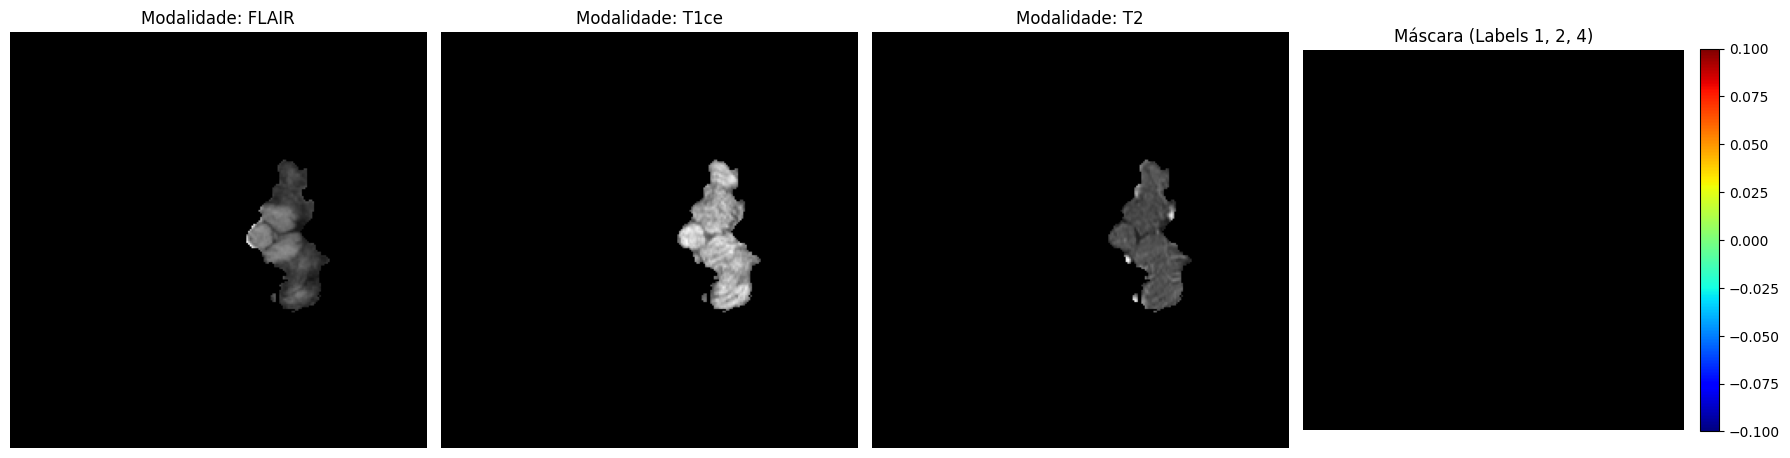

In [8]:
# No BraTS .h5 do Kaggle, as modalidades costumam ser: 0:FLAIR, 1:T1ce, 2:T2
modalities = ['FLAIR', 'T1ce', 'T2']

plt.figure(figsize=(18, 5))

# Plot das Modalidades
for i in range(3):
  plt.subplot(1, 4, i+1)
  plt.title(f"Modalidade: {modalities[i]}")
  plt.imshow(data[:, :, i], cmap='gray')
  plt.axis('off')

# Plot da Máscara (Ground Truth)
plt.subplot(1, 4, 4)
plt.title("Máscara (Labels 1, 2, 4)")
plt.imshow(mask, cmap='jet')
plt.colorbar(fraction=0.046, pad=0.04)
plt.axis('off')

plt.tight_layout()
plt.show()